In [21]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # Utilisation de Counter pour compter les occurrences des classes (Réussite/Échec)
import math # Importation du module math pour les fonctions logarithmiques nécessaires à l'entropie

# ==========================================
# 1. PRÉPARATION DES DONNÉES (DATASET)
# ==========================================
# Définition de la matrice des caractéristiques (notes par matière pour chaque étudiant)
etudiants = [
    [15,12,14,13,16,15], [8,9,7,10,8,9], [12,11,13,14,12,10], [5,6,7,8,5,6],
    [17,14,16,15,18,17], [9,10,8,9,11,10], [13,12,11,14,13,12], [4,5,6,5,4,5],
    [16,15,14,17,16,18], [7,8,9,7,8,7], [11,10,12,11,10,11], [6,7,5,6,7,6],
    [14,13,15,14,13,14], [10,9,10,11,9,10], [18,17,16,18,17,18], [3,4,5,4,3,4],
    [12,13,12,11,14,13], [8,7,8,9,7,8], [15,16,15,14,15,16], [5,5,6,5,6,5]
]
# Liste des étiquettes (features) correspondant aux colonnes de la matrice X
features = ["Math", "Francais", "Anglais", "Systeme", "Architecture", "Assembleur"]

X = np.array(etudiants) # Conversion de la liste en tableau NumPy pour le calcul vectoriel

# Création du vecteur cible 'y' : on étiquette chaque étudiant selon sa moyenne générale
# Mathématiquement : y = f(X) où f est la condition de moyenne >= 10
y = np.array(["Réussite" if np.mean(e) >= 10 else "Échec" for e in etudiants])

In [22]:
def entropie(labels):
    """
    Calcule H(S) : Mesure de l'impureté ou du désordre du nœud actuel S
    Formule de Shannon : H(S) = - Σ p_i * log2(p_i)
    """
    total = len(labels) # Nombre total d'échantillons dans le nœud
    if total == 0: return 0 # Si le nœud est vide, l'entropie est nulle par définition
    compteur = Counter(labels) # Fréquence d'apparition de chaque classe (Réussite vs Échec)
    h = 0 # Initialisation de la valeur de l'entropie
    for v in compteur.values(): # Pour chaque classe présente dans le nœud
        p = v / total # p : Probabilité d'appartenance à la classe (p_i)
        h -= p * math.log2(p) # Somme pondérée des probabilités logarithmiques
    return h # Retourne l'entropie (H=0 si pur, H=1 si mélange 50/50)

def split_dataset(X, y, f, s):
    """
    Division binaire de l'espace des données selon une feature f et un seuil s
    C'est la base de la construction récursive de l'arbre.
    """
    mask = X[:, f] <= s # Création d'un masque booléen pour les valeurs inférieures ou égales au seuil
    # Retourne deux sous-ensembles : Gauche (Vrai) et Droite (Faux)
    return X[mask], y[mask], X[~mask], y[~mask]

def information_gain(p_labels, g_labels, d_labels):
    """
    Calcule IG (Information Gain) : La réduction d'incertitude obtenue après la division
    Formule : IG = H(Parent) - [ (Poids_Gauche * H(Gauche)) + (Poids_Droit * H(Droit)) ]
    """
    total = len(p_labels) # Taille du nœud parent
    # Calcul de l'entropie pondérée des deux nœuds enfants (Gauche et Droite)
    h_ponderee = (len(g_labels)/total)*entropie(g_labels) + (len(d_labels)/total)*entropie(d_labels)
    # Gain = Entropie avant division - Entropie après division
    return entropie(p_labels) - h_ponderee

In [23]:
def meilleur_split(X, y):
    """ Algorithme CART : Recherche exhaustive du meilleur couple (matière, seuil) """
    m_gain = -1 # Initialisation du gain maximum à une valeur négative
    m_feat = None # Stockage de l'indice du meilleur module
    m_seuil = None # Stockage de la meilleure valeur de coupure

    h_initiale = entropie(y) # Mesure de l'incertitude initiale avant toute division
    print(f"--- ANALYSE CART ---")
    print(f"Entropie initiale H(S) : {round(h_initiale, 4)}\n")

    for f in range(X.shape[1]): # Parcourt chaque matière (Math, Français, etc.)
        seuils = np.unique(X[:, f]) # Récupère les notes uniques pour servir de candidats au seuil
        for s in seuils: # Teste chaque note comme point de coupure potentiel
            gx, gy, dx, dy = split_dataset(X, y, f, s) # Simule la division
            if len(gy) > 0 and len(dy) > 0: # S'assure que le split ne produit pas de groupes vides
                gain = information_gain(y, gy, dy) # Calcule le gain d'information obtenu
                if gain > m_gain: # Si ce split est plus performant que le précédent
                    m_gain = gain # Mise à jour du gain maximal
                    m_feat = f # Mémorisation de la matière
                    m_seuil = s # Mémorisation du seuil

    # Affichage des résultats de la recherche du meilleur discriminateur
    print(f"RÉSULTAT DE L'OPTIMISATION :")
    print(f"Le meilleur module est : {features[m_feat]}")
    print(f"Le seuil de décision optimal est : {m_seuil}")
    print(f"Le Gain d'Information (IG) maximal est : {round(m_gain, 4)}")
    print("-" * 25 + "\n")

    return {"f": m_feat, "s": m_seuil, "g": m_gain}

# Lancement du calcul
analys = meilleur_split(X, y)

--- ANALYSE CART ---
Entropie initiale H(S) : 1.0

RÉSULTAT DE L'OPTIMISATION :
Le meilleur module est : Math
Le seuil de décision optimal est : 10
Le Gain d'Information (IG) maximal est : 1.0
-------------------------



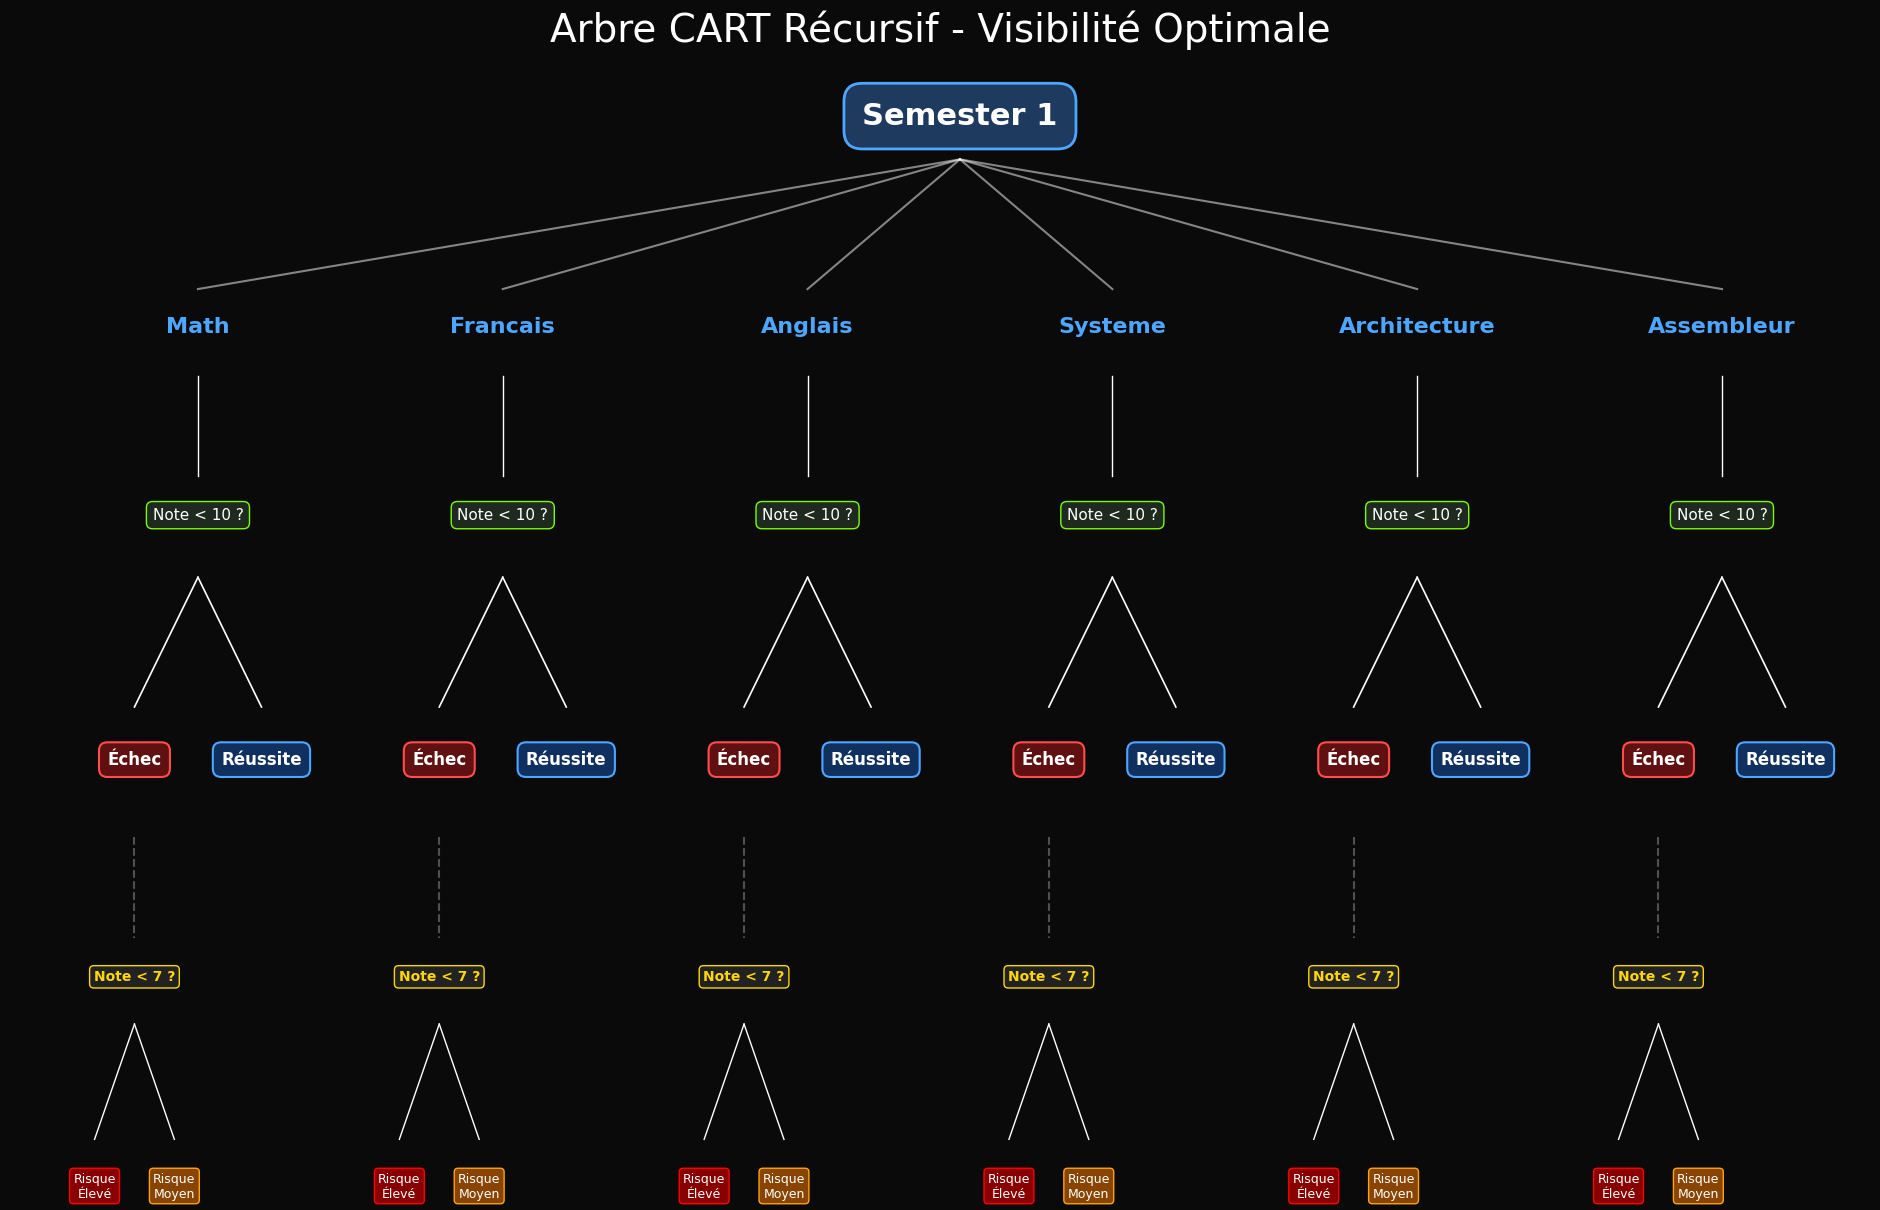

In [24]:
# ==========================================
# 3. VISUALISATION GRAPHIQUE
# ==========================================

fig, ax = plt.subplots(figsize=(24, 14)) # Création d'une toile de grande dimension pour la clarté
fig.patch.set_facecolor("#0A0A0A") # Définition du fond de la figure en noir profond
ax.set_facecolor("#0A0A0A") # Définition du fond de l'axe en noir profond
ax.axis('off') # Désactivation des axes X et Y (inutiles pour un diagramme d'arbre)

plt.title("Arbre CART Récursif - Visibilité Optimale", fontsize=28, color='white', pad=50) # Titre principal

# Dessin de la racine du système (Semestre 1)
ax.text(0.5, 0.95, "Semester 1", ha='center', va='center', fontsize=22, color='white', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#1E3A5F", edgecolor="#4DA6FF", linewidth=2))

# Calcul de la répartition horizontale uniforme des 6 matières (features)
pos = np.linspace(0.08, 0.92, len(features))

for i, mod in enumerate(features): # Boucle pour dessiner chaque branche de matière
    x = pos[i] # Position X actuelle du module
    # Tracé du lien entre la racine centrale et le module spécifique
    ax.plot([0.5, x], [0.92, 0.83], color='white', linewidth=1.5, alpha=0.5)

    # Affichage du nom de la matière au bout de la branche
    ax.text(x, 0.80, mod, ha='center', fontsize=16, fontweight='bold', color='#4DA6FF')

    # --- NIVEAU 1 : QUESTION DE DÉCISION ---
    ax.plot([x, x], [0.77, 0.70], color='white', linewidth=1) # Ligne verticale vers le test
    ax.text(x, 0.67, "Note < 10 ?", ha='center', fontsize=11, color='white',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#1F2A1F", edgecolor="#7CFC00"))

    # Positionnement des branches secondaires (Gauche=Échec, Droite=Réussite)
    xl, xr = x-0.035, x+0.035
    y_node1, y_leaf = 0.63, 0.50
    ax.plot([x, xl], [y_node1, y_leaf+0.04], color='white', linewidth=1.2) # Branche vers Échec
    ax.plot([x, xr], [y_node1, y_leaf+0.04], color='white', linewidth=1.2) # Branche vers Réussite

    # Dessin des feuilles finales (Nœuds terminaux)
    ax.text(xl, y_leaf, "Échec", ha='center', fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#601010", edgecolor="#FF4D4D", linewidth=1.5))
    ax.text(xr, y_leaf, "Réussite", ha='center', fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#103060", edgecolor="#4DA6FF", linewidth=1.5))

    # --- NIVEAU 2 : ANALYSE DES RISQUES (SOUS-ARBRE) ---
    y_risque_line = 0.45
    y_decision2 = 0.35
    # Ligne pointillée indiquant une analyse approfondie pour ceux en échec
    ax.plot([xl, xl], [y_risque_line, y_decision2+0.03], color='gray', linestyle='--', alpha=0.6)
    # Nouveau test binaire pour affiner le niveau d'échec
    ax.text(xl, y_decision2, "Note < 7 ?", ha='center', fontsize=10, color='#FFD700', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#222222", edgecolor="#FFD700"))

    xrl, xrr = xl-0.022, xl+0.022
    y_final = 0.20
    ax.plot([xl, xrl], [y_decision2-0.03, y_final+0.04], color='white', linewidth=1) # Branche vers Risque Élevé
    ax.plot([xl, xrr], [y_decision2-0.03, y_final+0.04], color='white', linewidth=1) # Branche vers Risque Moyen

    # Affichage des sous-catégories de risque
    ax.text(xrl, y_final, "Risque\nÉlevé", ha='center', fontsize=9, color='white',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#880000", edgecolor="#FF0000", linewidth=1))
    ax.text(xrr, y_final, "Risque\nMoyen", ha='center', fontsize=9, color='white',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#884400", edgecolor="#FFA500", linewidth=1))

plt.show() # Affichage final du graphique interactif